
# Script: 4-Keypoint Bézier Curve Assessment Engine

Description:
    This script evaluates a YOLO-Pose model trained to predict 4 control points 
    for a cubic Bézier curve. It compares model predictions against a strictly 
    annotated 4-point ground truth dataset.

    Metrics Calculated:
    1. Mean Endpoint Drift: The average Euclidean pixel distance between the 
       predicted and ground truth endpoints (Head and Tail / P0 and P3).
    2. Mean Length Error (%): The Mean Absolute Relative Error (MARE) comparing 
       the arc lengths of the discretized ground truth and predicted curves.
    3. Mean Chamfer Distance: A robust metric measuring the average pixel distance 
       between the overall shapes of the predicted and ground truth curves.
    4. Object Keypoint Similarity (OKS): The standard COCO metric for keypoint 
       accuracy, scaling positional error by the object's bounding box area.


In [1]:

import os
import cv2
import numpy as np
from scipy.spatial import distance
from ultralytics import YOLO

In [2]:



def calculate_iou(box1, box2):
    """Calculates Intersection over Union (IoU) between two bounding boxes [x1, y1, x2, y2]."""
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    return intersection_area / float(box1_area + box2_area - intersection_area)

def generate_bezier_curve(points, num_samples=100):
    """
    Generates discrete points along a cubic Bézier curve given 4 control points.
    points: Array of 4 control points [[x0,y0], [x1,y1], [x2,y2], [x3,y3]]
    """
    curve = np.zeros((num_samples, 2))
    for i, t in enumerate(np.linspace(0, 1, num_samples)):
        # Cubic Bézier Formula
        p = ( (1-t)**3 * points[0] + 
              3 * (1-t)**2 * t * points[1] + 
              3 * (1-t) * t**2 * points[2] + 
              t**3 * points[3] )
        curve[i] = p
    return curve

def bezier_arc_length(curve_points):
    """Calculates the total arc length by summing distances between discrete segments."""
    length = 0.0
    for i in range(1, len(curve_points)):
        length += np.linalg.norm(curve_points[i] - curve_points[i-1])
    return length

def calculate_chamfer_distance(curve_a, curve_b):
    """
    Calculates the symmetric Chamfer Distance between two sets of points.
    Measures the overall shape similarity between the two curves.
    """
    # Calculate pairwise distances between all points in A and all points in B
    dist_matrix = distance.cdist(curve_a, curve_b, 'euclidean')
    
    # Distance from each point in A to the closest point in B
    min_dist_a_to_b = np.min(dist_matrix, axis=1)
    # Distance from each point in B to the closest point in A
    min_dist_b_to_a = np.min(dist_matrix, axis=0)
    
    # Symmetric Chamfer distance is the mean of these nearest-neighbor distances
    chamfer = (np.mean(min_dist_a_to_b) + np.mean(min_dist_b_to_a)) / 2.0
    return chamfer

def calculate_oks(gt_kpts, pred_kpts, gt_box, kappa=0.0494):
    """
    Calculates Object Keypoint Similarity (OKS).
    kappa controls the falloff. 0.05 is standard for rigid/semi-rigid structures.
    """
    # Object scale (square root of bounding box area)
    box_w = gt_box[2] - gt_box[0]
    box_h = gt_box[3] - gt_box[1]
    scale = np.sqrt(box_w * box_h)
    
    # Avoid division by zero for extremely small/malformed boxes
    if scale < 1e-6:
        return 0.0
        
    distances = np.linalg.norm(pred_kpts - gt_kpts, axis=1)
    # OKS Formula: exp(-d^2 / (2 * s^2 * k^2))
    oks_scores = np.exp(-(distances**2) / (2 * (scale**2) * (kappa**2)))
    
    return np.mean(oks_scores)

def evaluate_bezier_model(weight_path, images_dir, labels_dir):
    print("\n" + "="*50)
    print(" INITIATING BÉZIER CURVE ASSESSMENT ENGINE")
    print("="*50)
    
    try:
        model = YOLO(weight_path)
    except Exception as e:
        print(f"[!] Failed to load model. Error: {e}")
        return

    # Accumulators for metrics
    total_valid_matches = 0
    
    sum_endpoint_drift = 0.0
    sum_length_error = 0.0
    sum_chamfer_dist = 0.0
    sum_oks = 0.0

    image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    total_images = len(image_files)
    
    print(f"[INFO] Found {total_images} images. Processing...\n")

    for idx, img_name in enumerate(image_files):
        img_path = os.path.join(images_dir, img_name)
        txt_name = os.path.splitext(img_name)[0] + ".txt"
        lbl_path = os.path.join(labels_dir, txt_name)
        
        if not os.path.exists(lbl_path):
            continue
            
        img = cv2.imread(img_path)
        if img is None:
            continue
            
        h_img, w_img = img.shape[:2]
        
        # Parse Ground Truth
        gt_objects = []
        with open(lbl_path, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            data = list(map(float, line.strip().split()))
            # Ensure it has class, box (4), and 4 keypoints with visibility (12) = 17 items total
            if len(data) < 17: 
                continue 
                
            cx, cy, w, h = data[1:5]
            gt_box = [
                (cx - w/2) * w_img, (cy - h/2) * h_img,
                (cx + w/2) * w_img, (cy + h/2) * h_img
            ]
            
            gt_kpts = []
            for i in range(5, 17, 3):
                gt_kpts.append(np.array([data[i] * w_img, data[i+1] * h_img]))
            gt_kpts = np.array(gt_kpts)
            
            gt_objects.append({'box': gt_box, 'kpts': gt_kpts})
            
        if not gt_objects:
            continue

        # Run Prediction
        results = model.predict(img_path, conf=0.25, verbose=False)
        result = results[0]
        
        if result.boxes is None or len(result.boxes) == 0:
            continue

        pred_boxes = result.boxes.xyxy.cpu().numpy()
        pred_keypoints = result.keypoints.xy.cpu().numpy()

        # Match Predictions to Ground Truths
        matched_preds = set()
        
        for gt in gt_objects:
            best_iou = 0
            best_idx = -1
            
            for i, pred_box in enumerate(pred_boxes):
                if i in matched_preds:
                    continue
                iou = calculate_iou(gt['box'], pred_box)
                if iou > best_iou:
                    best_iou = iou
                    best_idx = i
                    
            if best_idx != -1 and best_iou > 0.5:
                matched_preds.add(best_idx)
                
                # We have a valid True Positive match
                p_kpts = pred_keypoints[best_idx]
                g_kpts = gt['kpts']
                
                # 1. Endpoint Drift (Average of P0 and P3 drift)
                drift_p0 = np.linalg.norm(p_kpts[0] - g_kpts[0])
                drift_p3 = np.linalg.norm(p_kpts[3] - g_kpts[3])
                mean_drift = (drift_p0 + drift_p3) / 2.0
                sum_endpoint_drift += mean_drift
                
                # 2. Length Error (MARE)
                curve_gt = generate_bezier_curve(g_kpts, num_samples=100)
                curve_pred = generate_bezier_curve(p_kpts, num_samples=100)
                
                len_gt = bezier_arc_length(curve_gt)
                len_pred = bezier_arc_length(curve_pred)
                
                # Avoid division by zero if annotation is severely corrupted
                if len_gt > 1e-5:
                    relative_error = abs(len_pred - len_gt) / len_gt
                else:
                    relative_error = 0.0
                sum_length_error += relative_error
                
                # 3. Chamfer Distance
                chamfer = calculate_chamfer_distance(curve_gt, curve_pred)
                sum_chamfer_dist += chamfer
                
                # 4. Object Keypoint Similarity (OKS)
                oks = calculate_oks(g_kpts, p_kpts, gt['box'])
                sum_oks += oks
                
                total_valid_matches += 1

        # Periodic progress update
        if (idx + 1) % 50 == 0:
            print(f" -> Processed {idx + 1}/{total_images} images...")

    print("\n" + "="*50)
    print(" 4-KEYPOINT BÉZIER ASSESSMENT RESULTS")
    print("="*50)
    
    if total_valid_matches > 0:
        final_drift = sum_endpoint_drift / total_valid_matches
        final_length_err = (sum_length_error / total_valid_matches) * 100 # percentage
        final_chamfer = sum_chamfer_dist / total_valid_matches
        final_oks = sum_oks / total_valid_matches
        
        print(f"Total True Positives Assessed : {total_valid_matches}")
        print(f"Mean Endpoint Drift         : {final_drift:.2f} pixels")
        print(f"Mean Chamfer Distance Error : {final_chamfer:.2f} pixels")
        print(f"Mean Length Error (MARE)    : {final_length_err:.2f}%")
        print(f"Mean OKS                    : {final_oks:.4f} (1.0 is perfect)")
    else:
        print("[!] No valid matching predictions found.")
        print("[!] Ensure the model detects objects and IoU > 0.5 with ground truths.")
    print("="*50)



In [3]:
if __name__ == '__main__':
    # Define your specific paths to the isolated 4-point evaluation dataset
    WEIGHTS = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\ultralytics\runs\pose\BezierFusion\eamrf_training_run_with_Test_Set2\weights\best.pt"
    # EVAL_IMAGES = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_pose_estimation\all_test_images"
    # EVAL_LABELS = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_pose_estimation\all_test_labels"
    

    EVAL_IMAGES = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_pose_estimation\Hainan\images"
    EVAL_LABELS = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_pose_estimation\Hainan\labels"
    evaluate_bezier_model(WEIGHTS, EVAL_IMAGES, EVAL_LABELS)


 INITIATING BÉZIER CURVE ASSESSMENT ENGINE
[INFO] Found 27 images. Processing...


 4-KEYPOINT BÉZIER ASSESSMENT RESULTS
Total True Positives Assessed : 73
Mean Endpoint Drift         : 104.56 pixels
Mean Chamfer Distance Error : 43.75 pixels
Mean Length Error (MARE)    : 29.21%
Mean OKS                    : 0.3888 (1.0 is perfect)


## Qualitative Results

In [4]:


def calculate_iou(box1, box2):
    """Calculates Intersection over Union (IoU) between two bounding boxes."""
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    return intersection_area / float(box1_area + box2_area - intersection_area)

def generate_bezier_curve(points, num_samples=100):
    """Generates discrete points along a cubic Bézier curve."""
    curve = np.zeros((num_samples, 2))
    for i, t in enumerate(np.linspace(0, 1, num_samples)):
        p = ( (1-t)**3 * points[0] + 
              3 * (1-t)**2 * t * points[1] + 
              3 * (1-t) * t**2 * points[2] + 
              t**3 * points[3] )
        curve[i] = p
    return curve

def calculate_chamfer_distance(curve_a, curve_b):
    """Calculates the symmetric Chamfer Distance between two sets of points."""
    dist_matrix = distance.cdist(curve_a, curve_b, 'euclidean')
    min_dist_a_to_b = np.min(dist_matrix, axis=1)
    min_dist_b_to_a = np.min(dist_matrix, axis=0)
    return (np.mean(min_dist_a_to_b) + np.mean(min_dist_b_to_a)) / 2.0

def build_directories(base_dir):
    """Creates fresh output directories for the qualitative results."""
    dirs = {
        'best': os.path.join(base_dir, '1_Best_Cases'),
        'average': os.path.join(base_dir, '2_Average_Cases'),
        'worst': os.path.join(base_dir, '3_Worst_Cases')
    }
    for path in dirs.values():
        if os.path.exists(path):
            shutil.rmtree(path, ignore_errors=True)
        os.makedirs(path, exist_ok=True)
    return dirs

def get_padded_crop(img, box, padding=40):
    """Extracts a padded crop of the bounding box, staying within image bounds."""
    h, w = img.shape[:2]
    x1, y1, x2, y2 = map(int, box)
    
    px1 = max(0, x1 - padding)
    py1 = max(0, y1 - padding)
    px2 = min(w, x2 + padding)
    py2 = min(h, y2 + padding)
    
    crop = img[py1:py2, px1:px2].copy()
    offset = (px1, py1) # Return offset to adjust keypoints relative to the crop
    return crop, offset

def run_qualitative_analysis(weight_path, images_dir, labels_dir, output_dir, num_cases=15):
    print("\n" + "="*50)
    print(" INITIATING BÉZIER QUALITATIVE SORTING ENGINE")
    print("="*50)
    
    model = YOLO(weight_path)
    out_dirs = build_directories(output_dir)
    
    image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    all_instances = [] # Store every matched fish here
    
    print(f"[INFO] Scanning {len(image_files)} images and calculating errors...\n")

    for img_name in image_files:
        img_path = os.path.join(images_dir, img_name)
        txt_name = os.path.splitext(img_name)[0] + ".txt"
        lbl_path = os.path.join(labels_dir, txt_name)
        
        if not os.path.exists(lbl_path): continue
            
        img = cv2.imread(img_path)
        if img is None: continue
        h_img, w_img = img.shape[:2]
        
        # 1. Parse Ground Truth
        gt_objects = []
        with open(lbl_path, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            data = list(map(float, line.strip().split()))
            if len(data) < 17: continue 
                
            cx, cy, w, h = data[1:5]
            gt_box = [
                (cx - w/2) * w_img, (cy - h/2) * h_img,
                (cx + w/2) * w_img, (cy + h/2) * h_img
            ]
            
            gt_kpts = [np.array([data[i] * w_img, data[i+1] * h_img]) for i in range(5, 17, 3)]
            gt_objects.append({'box': gt_box, 'kpts': np.array(gt_kpts)})

        # 2. Get Predictions
        results = model.predict(img_path, conf=0.25, verbose=False)[0]
        if results.boxes is None or len(results.boxes) == 0: continue

        pred_boxes = results.boxes.xyxy.cpu().numpy()
        pred_keypoints = results.keypoints.xy.cpu().numpy()

        # 3. Match and Calculate Error
        matched_preds = set()
        
        for gt in gt_objects:
            best_iou, best_idx = 0, -1
            for i, pred_box in enumerate(pred_boxes):
                if i in matched_preds: continue
                iou = calculate_iou(gt['box'], pred_box)
                if iou > best_iou:
                    best_iou, best_idx = iou, i
                    
            if best_idx != -1 and best_iou > 0.5:
                matched_preds.add(best_idx)
                
                p_kpts = pred_keypoints[best_idx]
                g_kpts = gt['kpts']
                
                # Calculate Chamfer Error
                curve_gt = generate_bezier_curve(g_kpts)
                curve_pred = generate_bezier_curve(p_kpts)
                chamfer_err = calculate_chamfer_distance(curve_gt, curve_pred)
                
                all_instances.append({
                    'img_path': img_path,
                    'img_name': img_name,
                    'gt_box': gt['box'],
                    'gt_kpts': g_kpts,
                    'pred_kpts': p_kpts,
                    'error': chamfer_err
                })

    if not all_instances:
        print("[!] No valid matches found. Check your dataset or model.")
        return

    # Sort instances by shape error (Chamfer Distance)
    all_instances.sort(key=lambda x: x['error'])
    total_inst = len(all_instances)
    
    print(f"\n[INFO] Extracted {total_inst} valid instances.")
    print("[INFO] Rendering and saving top qualitative cases...")

    # Define the slices for Best, Average, and Worst
    mid_idx = total_inst // 2
    half_n = num_cases // 2
    
    categories = {
        'best': (all_instances[:num_cases], out_dirs['best']),
        'average': (all_instances[mid_idx - half_n : mid_idx + half_n + 1], out_dirs['average']),
        'worst': (all_instances[-num_cases:], out_dirs['worst'])
    }

    for cat_name, (instances, save_dir) in categories.items():
        for i, inst in enumerate(instances):
            img = cv2.imread(inst['img_path'])
            
            # Extract crop and offset
            crop, (off_x, off_y) = get_padded_crop(img, inst['gt_box'])
            
            # Adjust keypoints to the cropped space
            adj_gt_kpts = inst['gt_kpts'] - np.array([off_x, off_y])
            adj_pred_kpts = inst['pred_kpts'] - np.array([off_x, off_y])
            
            # Generate Curves
            curve_gt = np.int32(generate_bezier_curve(adj_gt_kpts))
            curve_pred = np.int32(generate_bezier_curve(adj_pred_kpts))
            
            # Draw GT Curve (Green)
            cv2.polylines(crop, [curve_gt], isClosed=False, color=(0, 255, 0), thickness=2, lineType=cv2.LINE_AA)
            for pt in adj_gt_kpts:
                cv2.circle(crop, (int(pt[0]), int(pt[1])), 4, (0, 255, 0), -1)
                
            # Draw Pred Curve (Red)
            cv2.polylines(crop, [curve_pred], isClosed=False, color=(0, 0, 255), thickness=2, lineType=cv2.LINE_AA)
            for pt in adj_pred_kpts:
                cv2.circle(crop, (int(pt[0]), int(pt[1])), 4, (0, 0, 255), -1)

            # Add Label Overlay
            err = inst['error']
            overlay = crop.copy()
            cv2.rectangle(overlay, (0, 0), (250, 40), (0, 0, 0), -1)
            cv2.addWeighted(overlay, 0.6, crop, 0.4, 0, crop)
            cv2.putText(crop, f"Chamfer Error: {err:.2f}px", (10, 25), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            
            # Save Image
            out_name = f"{i+1:02d}_Error_{err:.1f}_{inst['img_name']}"
            cv2.imwrite(os.path.join(save_dir, out_name), crop)

    print("\n" + "="*50)
    print(" EXPORT COMPLETE")
    print(f" -> Check the folders in: {output_dir}")
    print(" Green Line = Ground Truth | Red Line = Prediction")
    print("="*50)



In [8]:
if __name__ == '__main__':
    # Define your specific paths to the isolated 4-point evaluation dataset
    WEIGHTS = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\ultralytics\runs\pose\BezierFusion\eamrf_training_run_with_Test_Set2\weights\best.pt"
    EVAL_IMAGES = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_pose_estimation\all_test_images"
    EVAL_LABELS = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_pose_estimation\all_test_labels"
    OUTPUT_ANALYTICS = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\results\Bézier_Qualitative_Results"
    run_qualitative_analysis(WEIGHTS, EVAL_IMAGES, EVAL_LABELS, OUTPUT_ANALYTICS, num_cases=15)


 INITIATING BÉZIER QUALITATIVE SORTING ENGINE
[INFO] Scanning 76 images and calculating errors...


[INFO] Extracted 250 valid instances.
[INFO] Rendering and saving top qualitative cases...

 EXPORT COMPLETE
 -> Check the folders in: C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\results\Bézier_Qualitative_Results
 Green Line = Ground Truth | Red Line = Prediction


In [7]:
"""
================================================================================
Script: Bézier Error Distribution Plotter
================================================================================
Description:
    This script evaluates the 4-keypoint Bézier YOLO-Pose model, extracts the 
    four core evaluation metrics (Endpoint Drift, Length Error, Chamfer Distance, 
    and OKS) for every individual valid detection, and plots their distributions.

    Outputs:
    1. error_distributions.png: A high-resolution 2x2 grid of histograms showing 
       the spread of errors across the entire dataset. Includes KDE (Kernel 
       Density Estimate) trend lines and Mean/Median markers.
    2. bezier_error_metrics.csv: A raw data export of every matched instance 
       for further statistical analysis.
================================================================================
"""

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance
from ultralytics import YOLO

# --- Helper Functions (Math & Geometry) ---
def calculate_iou(box1, box2):
    x_left, y_top = max(box1[0], box2[0]), max(box1[1], box2[1])
    x_right, y_bottom = min(box1[2], box2[2]), min(box1[3], box2[3])
    if x_right < x_left or y_bottom < y_top: return 0.0
    intersection = (x_right - x_left) * (y_bottom - y_top)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    return intersection / float(area1 + area2 - intersection)

def generate_bezier_curve(points, num_samples=100):
    curve = np.zeros((num_samples, 2))
    for i, t in enumerate(np.linspace(0, 1, num_samples)):
        p = ((1-t)**3 * points[0] + 3*(1-t)**2*t * points[1] + 
             3*(1-t)*t**2 * points[2] + t**3 * points[3])
        curve[i] = p
    return curve

def bezier_arc_length(curve_points):
    length = 0.0
    for i in range(1, len(curve_points)):
        length += np.linalg.norm(curve_points[i] - curve_points[i-1])
    return length

def calculate_chamfer_distance(curve_a, curve_b):
    dist_matrix = distance.cdist(curve_a, curve_b, 'euclidean')
    return (np.mean(np.min(dist_matrix, axis=1)) + np.mean(np.min(dist_matrix, axis=0))) / 2.0

def calculate_oks(gt_kpts, pred_kpts, gt_box, kappa=0.04914):
    scale = np.sqrt((gt_box[2] - gt_box[0]) * (gt_box[3] - gt_box[1]))
    if scale < 1e-6: return 0.0
    distances = np.linalg.norm(pred_kpts - gt_kpts, axis=1)
    return np.mean(np.exp(-(distances**2) / (2 * (scale**2) * (kappa**2))))

# --- Main Evaluation & Plotting Logic ---
def plot_error_distributions(weight_path, images_dir, labels_dir, output_dir):
    print("\n" + "="*50)
    print(" EXTRACTING ERROR DISTRIBUTIONS")
    print("="*50)
    
    os.makedirs(output_dir, exist_ok=True)
    model = YOLO(weight_path)
    
    image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.png'))]
    all_metrics = []
    
    for idx, img_name in enumerate(image_files):
        img_path = os.path.join(images_dir, img_name)
        txt_name = os.path.splitext(img_name)[0] + ".txt"
        lbl_path = os.path.join(labels_dir, txt_name)
        
        if not os.path.exists(lbl_path): continue
        
        img = cv2.imread(img_path)
        if img is None: continue
        h_img, w_img = img.shape[:2]
        
        # Parse Ground Truth
        gt_objects = []
        with open(lbl_path, 'r') as f:
            for line in f:
                data = list(map(float, line.strip().split()))
                if len(data) < 17: continue 
                cx, cy, w, h = data[1:5]
                gt_box = [(cx - w/2)*w_img, (cy - h/2)*h_img, (cx + w/2)*w_img, (cy + h/2)*h_img]
                gt_kpts = np.array([[data[i]*w_img, data[i+1]*h_img] for i in range(5, 17, 3)])
                gt_objects.append({'box': gt_box, 'kpts': gt_kpts})
                
        if not gt_objects: continue

        # Predictions
        results = model.predict(img_path, conf=0.25, verbose=False)[0]
        if results.boxes is None or len(results.boxes) == 0: continue

        pred_boxes = results.boxes.xyxy.cpu().numpy()
        pred_keypoints = results.keypoints.xy.cpu().numpy()
        matched_preds = set()
        
        for gt in gt_objects:
            best_iou, best_idx = 0, -1
            for i, pred_box in enumerate(pred_boxes):
                if i in matched_preds: continue
                iou = calculate_iou(gt['box'], pred_box)
                if iou > best_iou: best_iou, best_idx = iou, i
                    
            if best_idx != -1 and best_iou > 0.5:
                matched_preds.add(best_idx)
                p_kpts, g_kpts = pred_keypoints[best_idx], gt['kpts']
                
                # 1. Endpoint Drift
                mean_drift = (np.linalg.norm(p_kpts[0] - g_kpts[0]) + np.linalg.norm(p_kpts[3] - g_kpts[3])) / 2.0
                
                # 2. Length Error
                curve_gt = generate_bezier_curve(g_kpts)
                curve_pred = generate_bezier_curve(p_kpts)
                len_gt = bezier_arc_length(curve_gt)
                len_pred = bezier_arc_length(curve_pred)
                rel_err = (abs(len_pred - len_gt) / len_gt * 100) if len_gt > 1e-5 else 0.0
                
                # 3. Chamfer
                chamfer = calculate_chamfer_distance(curve_gt, curve_pred)
                
                # 4. OKS
                oks = calculate_oks(g_kpts, p_kpts, gt['box'])
                
                all_metrics.append({
                    'Image': img_name,
                    'Chamfer Distance (px)': chamfer,
                    'Length Error (%)': rel_err,
                    'Endpoint Drift (px)': mean_drift,
                    'OKS': oks
                })

    if not all_metrics:
        print("[!] No data to plot. Check predictions.")
        return

    # --- Convert to DataFrame and Export ---
    df = pd.DataFrame(all_metrics)
    csv_path = os.path.join(output_dir, "bezier_error_metrics.csv")
    df.to_csv(csv_path, index=False)
    print(f"\n[+] Raw metrics saved to {csv_path}")

    # --- Plotting Distributions ---
    print("[+] Generating distribution plots...")
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    
    metrics_config = [
        ('Chamfer Distance (px)', axs[0, 0], 'purple', 'lower'),
        ('OKS', axs[0, 1], 'orange', 'higher'),
        ('Length Error (%)', axs[1, 0], 'teal', 'lower'),
        ('Endpoint Drift (px)', axs[1, 1], 'magenta', 'lower')
    ]

    for metric, ax, color, ideal in metrics_config:
        sns.histplot(data=df, x=metric, kde=True, ax=ax, color=color, bins=30, alpha=0.6)
        
        mean_val = df[metric].mean()
        median_val = df[metric].median()
        
        # Add Mean and Median lines
        ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
        ax.axvline(median_val, color='black', linestyle=':', linewidth=1.5, label=f'Median: {median_val:.2f}')
        
        ax.set_title(f"Distribution of {metric}")
        ax.set_ylabel("Frequency (Fish Count)")
        ax.legend()

    plt.suptitle("Bézier Curve Prediction Error Distributions", fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    plot_path = os.path.join(output_dir, "error_distributions.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"[+] High-resolution plot saved to {plot_path}")
    
    # Show plot briefly if running in an interactive environment
    plt.show()




 EXTRACTING ERROR DISTRIBUTIONS

[+] Raw metrics saved to C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\results\Bézier_Qualitative_Results\bezier_error_metrics.csv
[+] Generating distribution plots...
[+] High-resolution plot saved to C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\results\Bézier_Qualitative_Results\error_distributions.png


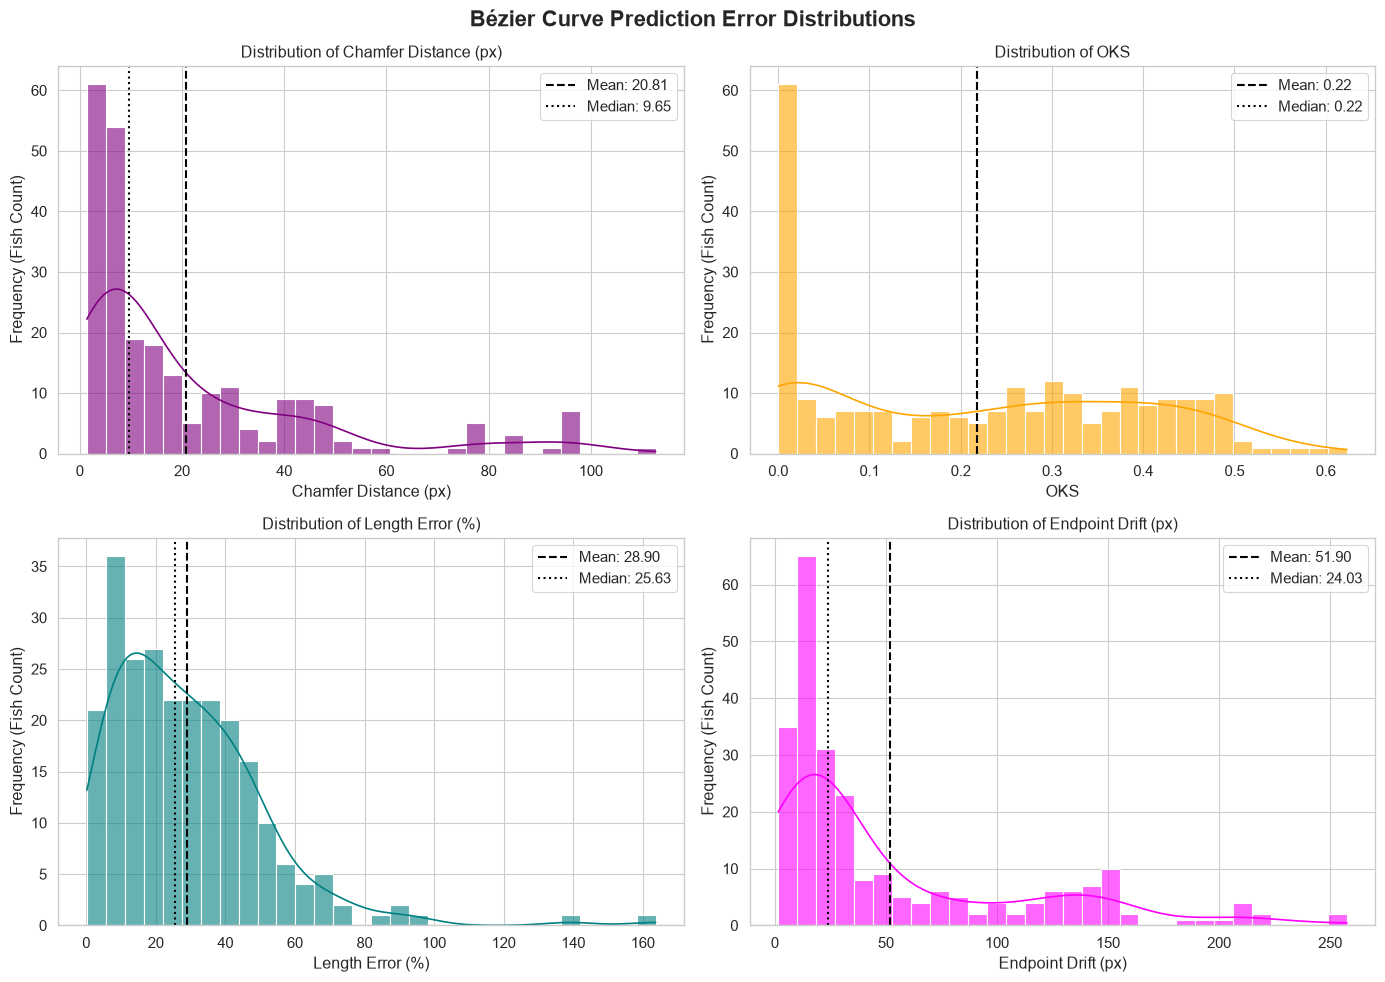

In [8]:
if __name__ == '__main__':
    # Define your specific paths to the isolated 4-point evaluation dataset
    WEIGHTS = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\ultralytics\runs\pose\BezierFusion\eamrf_training_run_with_Test_Set2\weights\best.pt"
    EVAL_IMAGES = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_pose_estimation\all_test_images"
    EVAL_LABELS = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_pose_estimation\all_test_labels"
    OUTPUT_ANALYTICS = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\results\Bézier_Qualitative_Results"
    plot_error_distributions(WEIGHTS, EVAL_IMAGES, EVAL_LABELS, OUTPUT_ANALYTICS)